In [1]:
!pip -q install transformers datasets underthesea openpyxl accelerate scikit-learn

In [2]:
import pandas as pd
import torch
import re
from datasets import Dataset
from transformers import AutoTokenizer, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from underthesea import word_tokenize
from google.colab import files

uploaded = files.upload()

Saving test.xlsx to test (1).xlsx
Saving train.xlsx to train (1).xlsx
Saving val.xlsx to val (1).xlsx


In [3]:
train_df = pd.read_excel("train.xlsx")
val_df = pd.read_excel("val.xlsx")
test_df = pd.read_excel("test.xlsx")

train_df = train_df.rename(columns={"content": "text"})
val_df = val_df.rename(columns={"content": "text"})
test_df = test_df.rename(columns={"content": "text"})

print("TRAIN COLUMNS:", train_df.columns.tolist())
print("VAL COLUMNS:", val_df.columns.tolist())
print("TEST COLUMNS:", test_df.columns.tolist())

display(train_df.head())

TRAIN COLUMNS: ['text', 'label', 'target_binary']
VAL COLUMNS: ['text', 'label', 'target_binary']
TEST COLUMNS: ['text', 'label', 'target_binary']


,text,label,target_binary
0,Lừa dối khách hàng,0,0
1,"ACCA, VNCPA CFA level 2 là cục cít lun rùi pk a",0,0
2,"chả làm đéo gì cũng gần 600 điểm đây, Bọn bank...",2,1
3,Page của mày h xàm loz quá....riết toàn ngta z...,2,1
4,Dân InDo thì m nge làm lol gì??? K thích t...,0,0


In [4]:
vietnamese_stopwords = set([
    "là","và","của","thì","những","các","tại","bị","bởi","với",
    "để","như","này","đó","kia","trong","trên","dưới","cho",
    "về","khi","có","không","gì","nào","đâu","rồi","lại"
])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in vietnamese_stopwords]
    return " ".join(words)

def vietnamese_tokenize(text):
    if not text:
        return ""
    return word_tokenize(text, format="text")

def preprocess(df):
    df = df.copy()
    df["text"] = df["text"].apply(clean_text)
    df["text"] = df["text"].apply(vietnamese_tokenize)
    return df

train_df = preprocess(train_df)
val_df = preprocess(val_df)
test_df = preprocess(test_df)

In [5]:
train_df = train_df[["text", "label", "target_binary"]].copy()
val_df = val_df[["text", "label", "target_binary"]].copy()
test_df = test_df[["text", "label", "target_binary"]].copy()

train_df["label"] = train_df["label"].astype(int)
train_df["target_binary"] = train_df["target_binary"].astype(int)

val_df["label"] = val_df["label"].astype(int)
val_df["target_binary"] = val_df["target_binary"].astype(int)

test_df["label"] = test_df["label"].astype(int)
test_df["target_binary"] = test_df["target_binary"].astype(int)

print(train_df.dtypes)
display(train_df.head())

text             object
label             int64
target_binary     int64
dtype: object


,text,label,target_binary
0,lừa_dối khách_hàng,0,0
1,acca vncpa cfa level 2 cục cít lun rùi pk a,0,0
2,chả làm đéo cũng gần 600 điểm đây bọn bank rác...,2,1
3,page mày h xàm loz quá riết toàn ngta_zô chửi ...,2,1
4,dân indo thi m nge la m lol gi k thi ch thi câ...,0,0


In [6]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset.column_names)
print(val_dataset.column_names)
print(test_dataset.column_names)

['text', 'label', 'target_binary']
['text', 'label', 'target_binary']
['text', 'label', 'target_binary']


In [7]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/13200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1650 [00:00<?, ? examples/s]

Map:   0%|          | 0/1650 [00:00<?, ? examples/s]

In [8]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label", "target_binary"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label", "target_binary"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label", "target_binary"]
)

print(train_dataset[0].keys())
print(val_dataset[0].keys())

dict_keys(['label', 'target_binary', 'input_ids', 'attention_mask'])
dict_keys(['label', 'target_binary', 'input_ids', 'attention_mask'])


In [9]:
sample = train_dataset[0]
print("Sample keys:", sample.keys())
for k, v in sample.items():
    try:
        print(k, v.shape if hasattr(v, "shape") else type(v), v)
    except:
        print(k, type(v), v)

Sample keys: dict_keys(['label', 'target_binary', 'input_ids', 'attention_mask'])
label torch.Size([]) tensor(0)
target_binary torch.Size([]) tensor(0)
input_ids torch.Size([128]) tensor([    0, 10362,   478,     2,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     

In [20]:
import torch.nn as nn
from transformers import AutoModel

class PhoBERT_MTL(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("vinai/phobert-base")
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.3)

        # Head 1: main label 3-class
        self.classifier_label = nn.Linear(hidden_size, 3)

        # Head 2: target binary 2-class
        self.classifier_target = nn.Linear(hidden_size, 2)

    def forward(self, input_ids, attention_mask, label=None, target_binary=None, **kwargs):
        # Handle the case where the Trainer passes 'labels' instead of 'label'
        if label is None and "labels" in kwargs:
            label = kwargs["labels"]

        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)

        logits_label = self.classifier_label(pooled_output)
        logits_target = self.classifier_target(pooled_output)

        loss = None
        if label is not None and target_binary is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss_label = loss_fct(logits_label, label)
            loss_target = loss_fct(logits_target, target_binary)
            loss = loss_label + loss_target

        return {
            "loss": loss,
            "logits_label": logits_label,
            "logits_target": logits_target
        }

model = PhoBERT_MTL()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    remove_unused_columns=False,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [22]:
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("label")
        targets = inputs.pop("target_binary")

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            label=labels,
            target_binary=targets
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

In [23]:
# Re-defining the CustomTrainer to fix the NoneType loss and column naming error
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Check for both 'label' and 'labels' as the Trainer sometimes renames them
        labels = inputs.get("label") if inputs.get("label") is not None else inputs.get("labels")
        targets = inputs.get("target_binary")

        if labels is None or targets is None:
            raise ValueError(f"Required columns 'label' (or 'labels') or 'target_binary' not found in inputs. Available: {list(inputs.keys())}")

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            label=labels,
            target_binary=targets
        )

        loss = outputs["loss"]

        if loss is None:
            raise ValueError("Model returned None for loss. Check the forward pass logic.")

        return (loss, outputs) if return_outputs else loss

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.644859,No log
2,0.194152,No log
3,0.116339,No log


TrainOutput(global_step=2475, training_loss=0.2670273952291469, metrics={'train_runtime': 1017.1181, 'train_samples_per_second': 38.934, 'train_steps_per_second': 2.433, 'total_flos': 0.0, 'train_loss': 0.2670273952291469, 'epoch': 3.0})

In [24]:
LABEL_MAP = {
    0: "CLEAN",
    1: "OFFENSIVE",
    2: "HATE"
}

TARGET_MAP = {
    0: "NON_TARGET",
    1: "TARGET"
}

def map_action(label_pred, target_pred):
    if label_pred == 0:
        return "ALLOW"
    elif label_pred == 1 and target_pred == 0:
        return "WARN"
    elif label_pred == 1 and target_pred == 1:
        return "BLOCK"
    elif label_pred == 2:
        return "AUTO_BLOCK"
    return "REVIEW"

def predict_text(text):
    cleaned = clean_text(text)
    tokenized = vietnamese_tokenize(cleaned)

    inputs = tokenizer(
        tokenized,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(next(model.parameters()).device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

        probs_label = torch.softmax(outputs["logits_label"], dim=-1)
        probs_target = torch.softmax(outputs["logits_target"], dim=-1)

        label_pred = torch.argmax(probs_label, dim=-1).item()
        target_pred = torch.argmax(probs_target, dim=-1).item()

        label_conf = probs_label[0][label_pred].item()
        target_conf = probs_target[0][target_pred].item()

    action = map_action(label_pred, target_pred)

    return {
        "text": text,
        "label_id": label_pred,
        "label_name": LABEL_MAP[label_pred],
        "label_confidence": round(label_conf, 4),
        "target_id": target_pred,
        "target_name": TARGET_MAP[target_pred],
        "target_confidence": round(target_conf, 4),
        "action": action
    }

In [25]:
samples = [
    "Shop giao hàng nhanh quá",
    "dm cái mạng này",
    "mày ngu quá",
    "bọn miền bắc đúng là rác rưởi",
    "đúng là giang hồ vui :)",
    "còn cái loại mày súc vật"
]

for s in samples:
    print(predict_text(s))

{'text': 'Shop giao hàng nhanh quá', 'label_id': 0, 'label_name': 'CLEAN', 'label_confidence': 0.9972, 'target_id': 0, 'target_name': 'NON_TARGET', 'target_confidence': 0.998, 'action': 'ALLOW'}
{'text': 'dm cái mạng này', 'label_id': 1, 'label_name': 'OFFENSIVE', 'label_confidence': 0.9976, 'target_id': 0, 'target_name': 'NON_TARGET', 'target_confidence': 0.9965, 'action': 'WARN'}
{'text': 'mày ngu quá', 'label_id': 2, 'label_name': 'HATE', 'label_confidence': 0.9978, 'target_id': 1, 'target_name': 'TARGET', 'target_confidence': 0.9989, 'action': 'AUTO_BLOCK'}
{'text': 'bọn miền bắc đúng là rác rưởi', 'label_id': 2, 'label_name': 'HATE', 'label_confidence': 0.9977, 'target_id': 1, 'target_name': 'TARGET', 'target_confidence': 0.9989, 'action': 'AUTO_BLOCK'}
{'text': 'đúng là giang hồ vui :)', 'label_id': 0, 'label_name': 'CLEAN', 'label_confidence': 0.9969, 'target_id': 0, 'target_name': 'NON_TARGET', 'target_confidence': 0.9982, 'action': 'ALLOW'}
{'text': 'còn cái loại mày súc vật',

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_label_preds = []
all_target_preds = []

for row in test_df["text"].tolist():
    out = predict_text(row)
    all_label_preds.append(out["label_id"])
    all_target_preds.append(out["target_id"])

y_label_true = test_df["label"].tolist()
y_target_true = test_df["target_binary"].tolist()

print("=== MAIN LABEL REPORT ===")
print(classification_report(y_label_true, all_label_preds, target_names=["CLEAN", "OFFENSIVE", "HATE"]))

print("=== TARGET BINARY REPORT ===")
print(classification_report(y_target_true, all_target_preds, target_names=["NON_TARGET", "TARGET"]))

print("=== CONFUSION MATRIX: MAIN LABEL ===")
print(confusion_matrix(y_label_true, all_label_preds))

print("=== CONFUSION MATRIX: TARGET ===")
print(confusion_matrix(y_target_true, all_target_preds))

=== MAIN LABEL REPORT ===
              precision    recall  f1-score   support

       CLEAN       0.97      0.98      0.97       848
   OFFENSIVE       0.97      0.97      0.97       364
        HATE       0.97      0.96      0.97       438

    accuracy                           0.97      1650
   macro avg       0.97      0.97      0.97      1650
weighted avg       0.97      0.97      0.97      1650

=== TARGET BINARY REPORT ===
              precision    recall  f1-score   support

  NON_TARGET       0.99      0.99      0.99      1036
      TARGET       0.99      0.99      0.99       614

    accuracy                           0.99      1650
   macro avg       0.99      0.99      0.99      1650
weighted avg       0.99      0.99      0.99      1650

=== CONFUSION MATRIX: MAIN LABEL ===
[[827  10  11]
 [  8 353   3]
 [ 14   2 422]]
=== CONFUSION MATRIX: TARGET ===
[[1027    9]
 [   7  607]]


In [28]:
text = input("Nhập câu cần test: ")
result = predict_text(text)
print(result)

Nhập câu cần test: mày đi ăn cứt đi 
{'text': 'mày đi ăn cứt đi ', 'label_id': 2, 'label_name': 'HATE', 'label_confidence': 0.9575, 'target_id': 1, 'target_name': 'TARGET', 'target_confidence': 0.9997, 'action': 'AUTO_BLOCK'}


In [29]:
save_path = "./phobert_mtl_model"

torch.save(model.state_dict(), f"{save_path}.pth")
tokenizer.save_pretrained(save_path)

print("Đã lưu model xong.")

Đã lưu model xong.


In [30]:
!pip -q install matplotlib seaborn

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [32]:
model.eval()

all_label_preds = []
all_target_preds = []

for row in test_df["text"].tolist():
    out = predict_text(row)
    all_label_preds.append(out["label_id"])
    all_target_preds.append(out["target_id"])

y_label_true = np.array(test_df["label"].tolist())
y_target_true = np.array(test_df["target_binary"].tolist())

all_label_preds = np.array(all_label_preds)
all_target_preds = np.array(all_target_preds)

label_names = ["CLEAN", "OFFENSIVE", "HATE"]
target_names = ["NON_TARGET", "TARGET"]

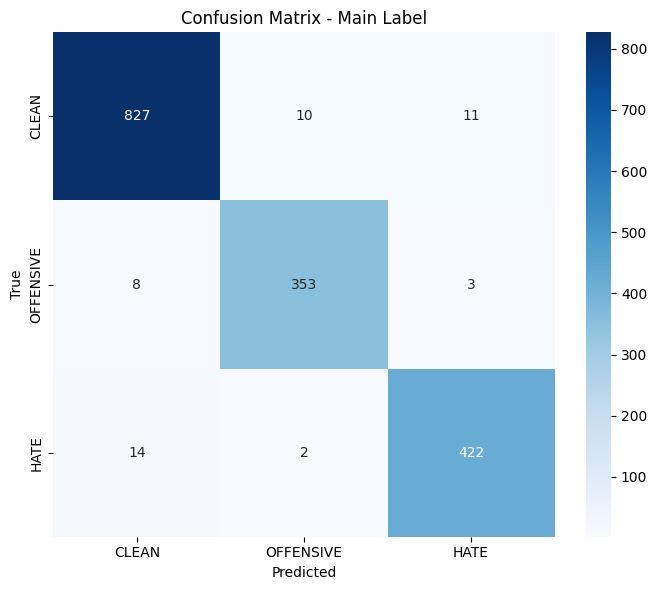

In [33]:
cm_label = confusion_matrix(y_label_true, all_label_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_label,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix - Main Label")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

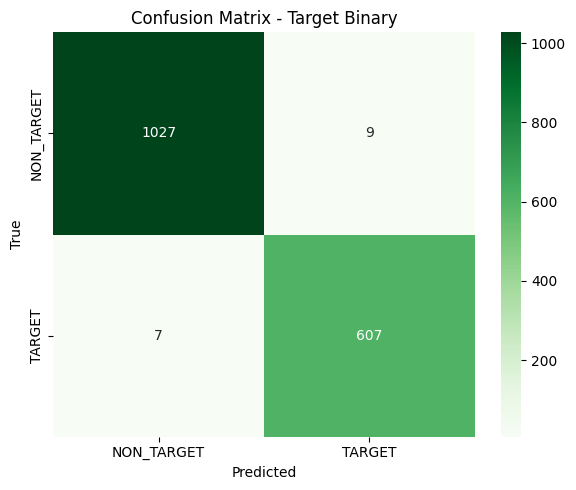

In [34]:
cm_target = confusion_matrix(y_target_true, all_target_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_target,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix - Target Binary")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

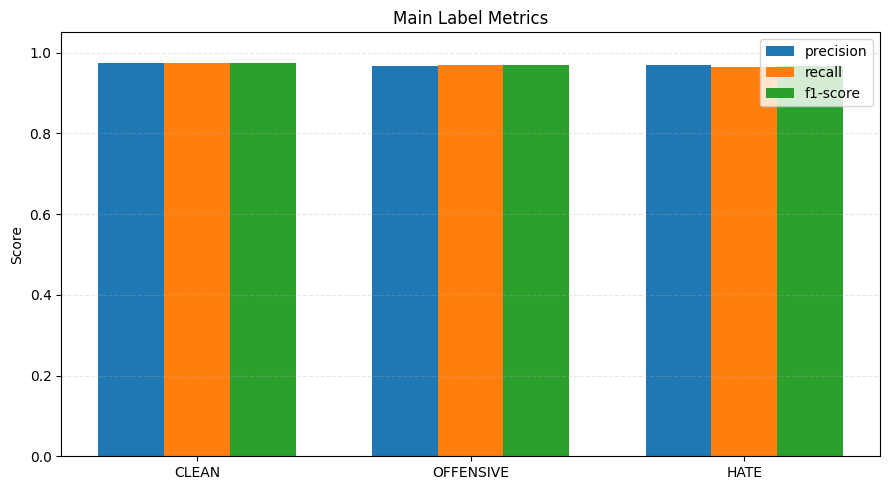

In [35]:
report_label = classification_report(
    y_label_true,
    all_label_preds,
    target_names=label_names,
    output_dict=True
)

metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(label_names))
width = 0.24

plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics):
    values = [report_label[name][metric] for name in label_names]
    plt.bar(x + i * width - width, values, width=width, label=metric)

plt.xticks(x, label_names)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Main Label Metrics")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

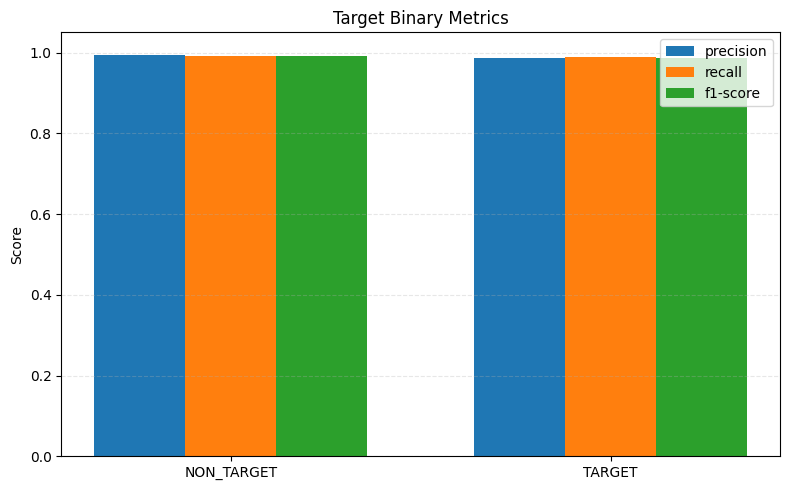

In [36]:
report_target = classification_report(
    y_target_true,
    all_target_preds,
    target_names=target_names,
    output_dict=True
)

metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(target_names))
width = 0.24

plt.figure(figsize=(8, 5))
for i, metric in enumerate(metrics):
    values = [report_target[name][metric] for name in target_names]
    plt.bar(x + i * width - width, values, width=width, label=metric)

plt.xticks(x, target_names)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Target Binary Metrics")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

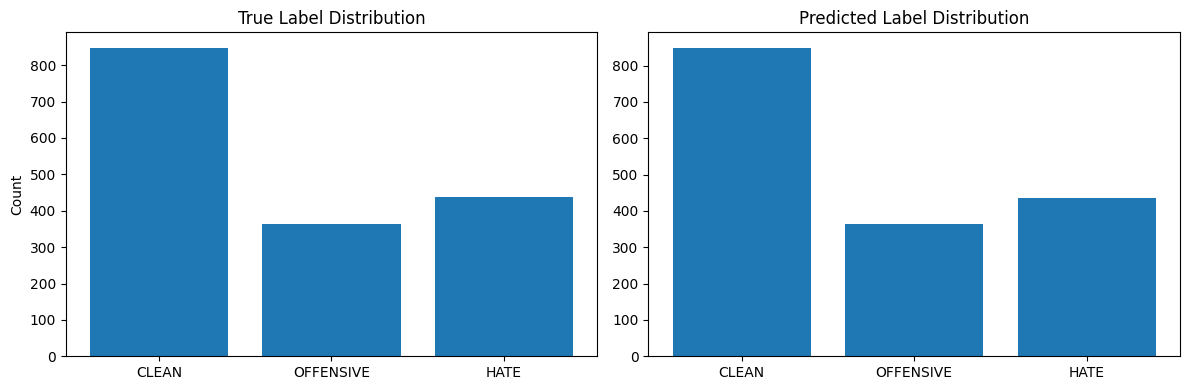

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

true_counts = [np.sum(y_label_true == i) for i in range(3)]
pred_counts = [np.sum(all_label_preds == i) for i in range(3)]

axes[0].bar(label_names, true_counts)
axes[0].set_title("True Label Distribution")
axes[0].set_ylabel("Count")

axes[1].bar(label_names, pred_counts)
axes[1].set_title("Predicted Label Distribution")

plt.tight_layout()
plt.show()

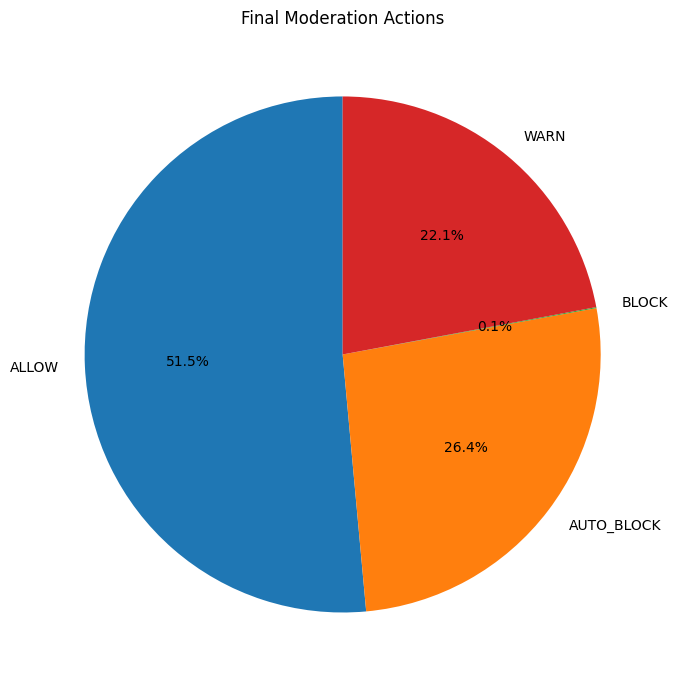

In [38]:
def map_action(label_pred, target_pred):
    if label_pred == 0:
        return "ALLOW"
    elif label_pred == 1 and target_pred == 0:
        return "WARN"
    elif label_pred == 1 and target_pred == 1:
        return "BLOCK"
    elif label_pred == 2:
        return "AUTO_BLOCK"
    return "REVIEW"

actions = [map_action(l, t) for l, t in zip(all_label_preds, all_target_preds)]

unique_actions = sorted(list(set(actions)))
action_counts = [actions.count(a) for a in unique_actions]

plt.figure(figsize=(7, 7))
plt.pie(action_counts, labels=unique_actions, autopct="%1.1f%%", startangle=90)
plt.title("Final Moderation Actions")
plt.tight_layout()
plt.show()

In [39]:
wrong_idx = np.where(y_label_true != all_label_preds)[0]

rows = []
for i in wrong_idx[:20]:
    rows.append({
        "text": test_df.iloc[i]["text"],
        "true_label": label_names[y_label_true[i]],
        "pred_label": label_names[all_label_preds[i]],
        "true_target": target_names[y_target_true[i]],
        "pred_target": target_names[all_target_preds[i]],
    })

wrong_df = pd.DataFrame(rows)
display(wrong_df)

,text,true_label,pred_label,true_target,pred_target
0,3 4 tháng nay vẫn vậy chứ tăng heo cá rau vẫn ...,HATE,CLEAN,TARGET,TARGET
1,mẹ vợ tôi 75 còn làm tiệc mừng_thọ nữa cụ 80 l...,HATE,CLEAN,TARGET,TARGET
2,nam thành cmt ông chỉ mang tính_chất_vả vào mồ...,OFFENSIVE,CLEAN,NON_TARGET,NON_TARGET
3,thôi chết_mẹ hôm nọ con mẹ nấm_thối kêu_gào ôn...,HATE,CLEAN,TARGET,TARGET
4,vã mèo tôm lắm r mà ông pô k xem,CLEAN,OFFENSIVE,NON_TARGET,NON_TARGET
5,sáp nhập cũng v thôi nhìn vt bd mà xem tết vừa...,CLEAN,OFFENSIVE,NON_TARGET,NON_TARGET
6,thay_vì ngồi xàm lol,CLEAN,OFFENSIVE,NON_TARGET,NON_TARGET
7,chữ nôm_hình nhiều từ trung_phồn_thể sau ghép ...,HATE,CLEAN,TARGET,TARGET
8,mất lập qua nổi_tiếng làm,CLEAN,OFFENSIVE,NON_TARGET,NON_TARGET
9,ước_muốn loại người hãy sống hết phần đời mình...,HATE,OFFENSIVE,TARGET,NON_TARGET


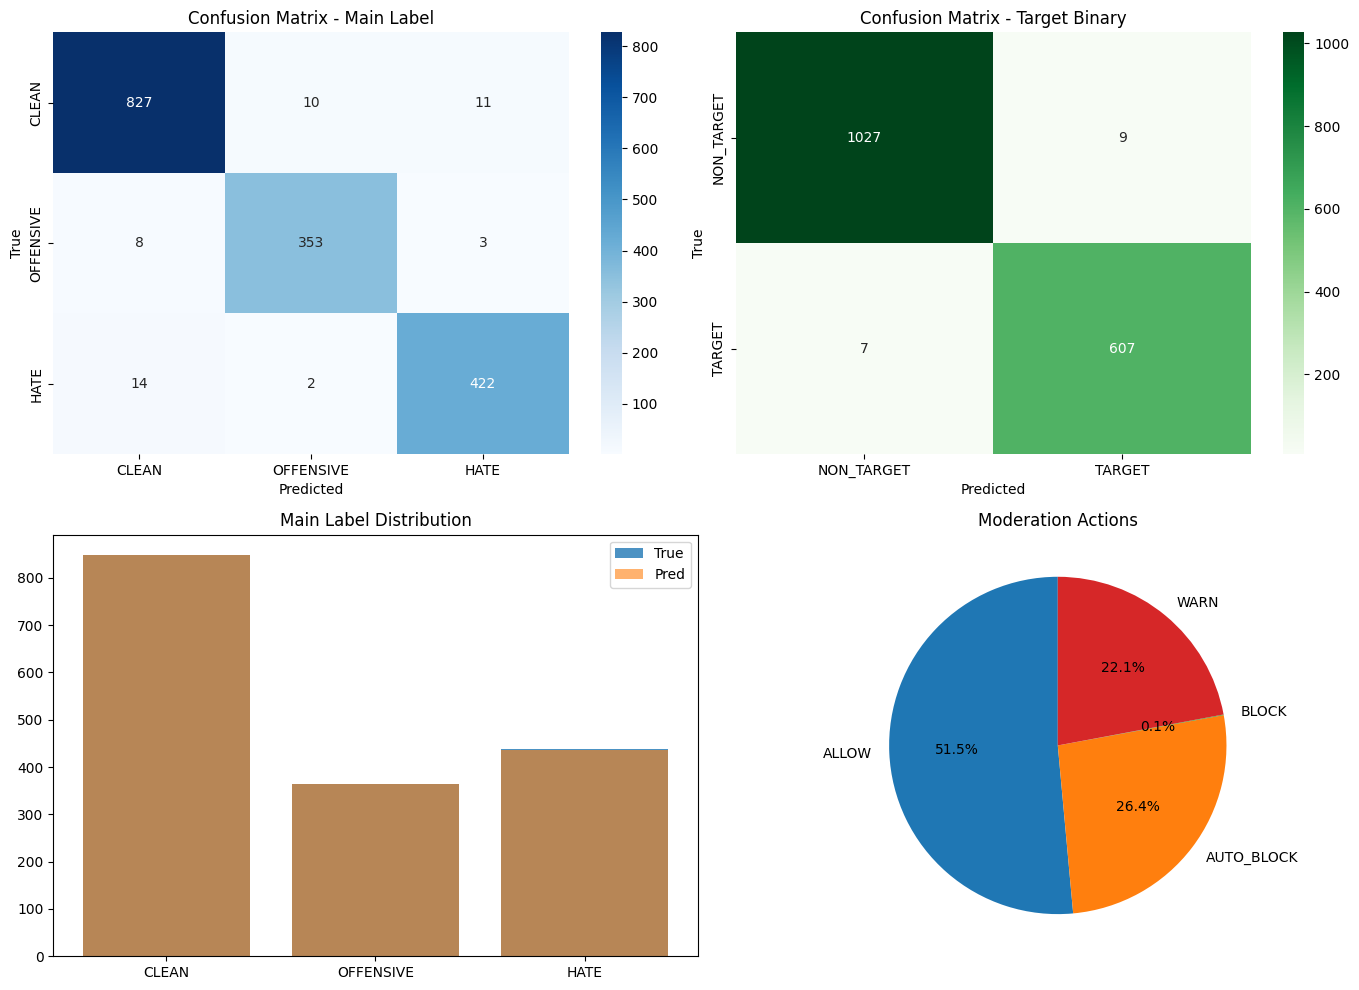

In [40]:
fig = plt.figure(figsize=(14, 10))

# 1. Main label CM
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(cm_label, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax1)
ax1.set_title("Confusion Matrix - Main Label")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")

# 2. Target CM
ax2 = plt.subplot(2, 2, 2)
sns.heatmap(cm_target, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names, ax=ax2)
ax2.set_title("Confusion Matrix - Target Binary")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")

# 3. Main label distribution
ax3 = plt.subplot(2, 2, 3)
ax3.bar(label_names, [np.sum(y_label_true == i) for i in range(3)], label="True", alpha=0.8)
ax3.bar(label_names, [np.sum(all_label_preds == i) for i in range(3)], label="Pred", alpha=0.6)
ax3.set_title("Main Label Distribution")
ax3.legend()

# 4. Action pie
ax4 = plt.subplot(2, 2, 4)
ax4.pie(action_counts, labels=unique_actions, autopct="%1.1f%%", startangle=90)
ax4.set_title("Moderation Actions")

plt.tight_layout()
plt.show()

In [41]:
save_path = "./phobert_mtl_model"

import os
os.makedirs(save_path, exist_ok=True)

# 1. lưu encoder (PhoBERT)
model.encoder.save_pretrained(save_path)

# 2. lưu tokenizer
tokenizer.save_pretrained(save_path)

# 3. lưu 2 head riêng
torch.save({
    "classifier_label": model.classifier_label.state_dict(),
    "classifier_target": model.classifier_target.state_dict()
}, f"{save_path}/heads.pth")

print("✅ Đã lưu model chuẩn deploy")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã lưu model chuẩn deploy


In [42]:
import torch
from transformers import AutoTokenizer, AutoModel

# load tokenizer
tokenizer = AutoTokenizer.from_pretrained("./phobert_mtl_model")

# load encoder
encoder = AutoModel.from_pretrained("./phobert_mtl_model")

# rebuild model
model = PhoBERT_MTL()
model.encoder = encoder

# load heads
heads = torch.load("./phobert_mtl_model/heads.pth")

model.classifier_label.load_state_dict(heads["classifier_label"])
model.classifier_target.load_state_dict(heads["classifier_target"])

model.eval()

print("✅ Load model thành công")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Load model thành công


In [43]:
print(predict_text("bọn miền bắc đúng là rác rưởi"))
print(predict_text("shop giao hàng nhanh"))

{'text': 'bọn miền bắc đúng là rác rưởi', 'label_id': 2, 'label_name': 'HATE', 'label_confidence': 0.9977, 'target_id': 1, 'target_name': 'TARGET', 'target_confidence': 0.9989, 'action': 'AUTO_BLOCK'}
{'text': 'shop giao hàng nhanh', 'label_id': 0, 'label_name': 'CLEAN', 'label_confidence': 0.9969, 'target_id': 0, 'target_name': 'NON_TARGET', 'target_confidence': 0.9982, 'action': 'ALLOW'}


In [44]:
import shutil

# nén thư mục model
shutil.make_archive("phobert_mtl_model", 'zip', "./phobert_mtl_model")

print("✅ Đã nén xong")

✅ Đã nén xong


In [45]:
from google.colab import files

files.download("phobert_mtl_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>